# Perfect 2D Face Mapping Comparison

This module extracts your facial wireframe (lips, eyes, eyebrows, nose, and jawline) and compares it directly to a perfectly normal, generic human face on a standardized coordinate grid.

In [7]:
def align_and_scale(landmarks_obj):
    """Aligns faces flawlessly: Centers on nose, rotates eyes horizontal, scales eye-width to 1.0."""
    import numpy as np
    if hasattr(landmarks_obj[0], 'x'):
        pts = np.array([[l.x, -l.y] for l in landmarks_obj])
    else:
        pts = np.array([[l['x'], -l['y']] for l in landmarks_obj])

    # --- SYNTHETIC FOREHEAD GENERATION ---
    top_oval_indices = [21, 54, 103, 67, 109, 10, 338, 297, 332, 284, 251]
    p_chin = pts[152]
    p_top = pts[10]
    face_height = ((p_chin[0] - p_top[0])**2 + (p_chin[1] - p_top[1])**2)**0.5
    center_x = p_top[0]
    
    for idx in top_oval_indices:
        p = pts[idx]
        sy = p[1] + (face_height * 0.22) # Y is UP, so ADD!
        sx = center_x + (p[0] - center_x) * 0.85
        pts[idx] = [sx, sy]
    # -------------------------------------

    # 1. Translate so nose (index 1) is exactly at (0,0)
    pts = pts - pts[1]
    
    # 2. Rotate so eyes (33 and 263) are perfectly horizontal
    left_eye = pts[33]
    right_eye = pts[263]
    angle = np.arctan2(right_eye[1] - left_eye[1], right_eye[0] - left_eye[0])
    c, s = np.cos(-angle), np.sin(-angle)
    R = np.array(((c, -s), (s, c)))
    pts = np.dot(pts, R.T)
    
    # 3. Scale so distance between eyes is exactly 1.0 unit
    left_eye = pts[33]
    right_eye = pts[263]
    eye_dist = np.linalg.norm(right_eye - left_eye)
    pts = pts / eye_dist
    
    return pts

In [8]:
import tkinter as tk
from tkinter import filedialog

print("Please select your Frontal Face Photo for the mapping...")
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
USER_IMG_PATH = filedialog.askopenfilename(
    title="Select Frontal Photo",
    filetypes=[("Images", "*.png *.jpg *.jpeg")]
)
root.destroy()

if not USER_IMG_PATH:
    raise ValueError("No image selected.")

print(f"Selected Your Face: {USER_IMG_PATH}")
print(f"Using: Realistic Average Human Face (468 points)")


Please select your Frontal Face Photo for the mapping...
Selected Your Face: C:/Users/PratikJPatel/Downloads/front.png
Using: Realistic Average Human Face (468 points)


Perfect Mapping complete! Saved as 2d_face_mapping.png


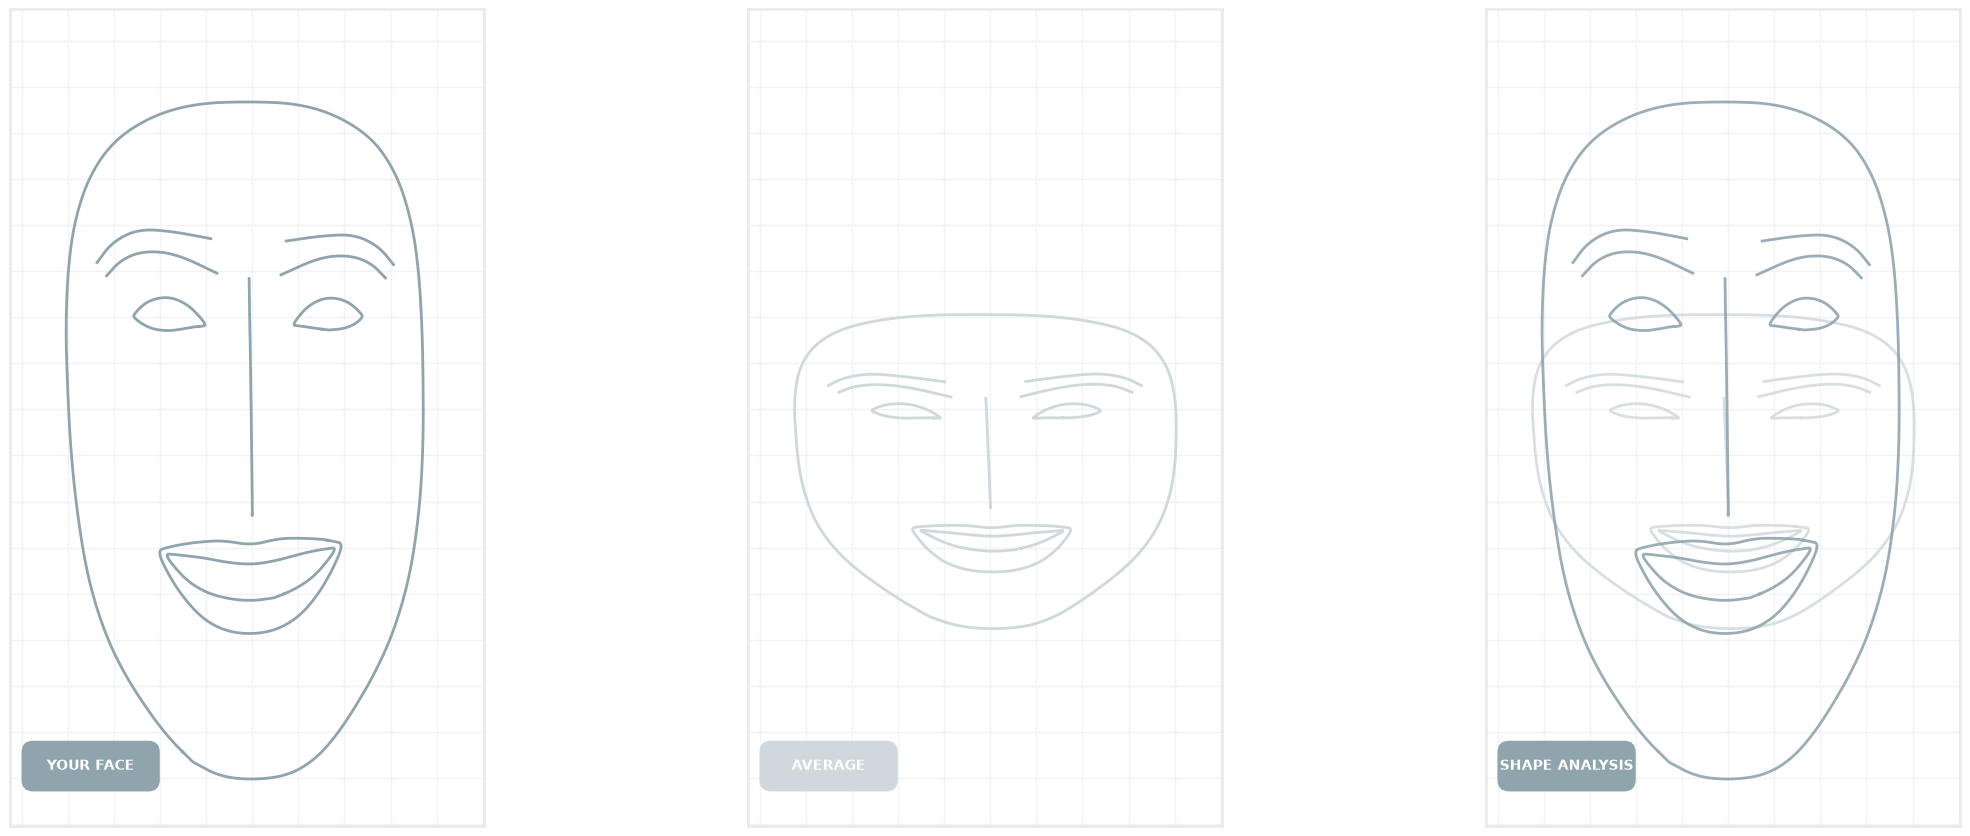

In [9]:
# --- CONTINUOUS SMOOTH CURVE ALGORITHMS ---
def order_edges(edges):
    adj = {}
    for u, v in edges:
        if u not in adj: adj[u] = []
        if v not in adj: adj[v] = []
        adj[u].append(v)
        adj[v].append(u)
        
    paths = []
    visited = set()
    
    for start_node in adj:
        if start_node in visited: continue
        
        curr = start_node
        for node in adj:
            if node not in visited and len(adj[node]) == 1:
                curr = node
                break
                
        path = [curr]
        visited.add(curr)
        
        while True:
            neighbors = [n for n in adj[curr] if n not in visited]
            if not neighbors: break
            curr = neighbors[0]
            path.append(curr)
            visited.add(curr)
            
        if len(adj[path[0]]) == 2 and len(adj[path[-1]]) == 2 and path[0] in adj[path[-1]]:
            path.append(path[0])
            
        paths.append(path)
    return paths

def chaikin_smooth(points, iterations=4, closed=False):
    if len(points) < 3: return points
    pts = np.array(points)
    for _ in range(iterations):
        if closed:
            p_next = np.roll(pts, -1, axis=0)
            pts_1 = 0.75 * pts + 0.25 * p_next
            pts_2 = 0.25 * pts + 0.75 * p_next
            new_pts = np.empty((pts.shape[0] * 2, pts.shape[1]))
            new_pts[0::2] = pts_1
            new_pts[1::2] = pts_2
            pts = new_pts
        else:
            p_next = pts[1:]
            pts_1 = 0.75 * pts[:-1] + 0.25 * p_next
            pts_2 = 0.25 * pts[:-1] + 0.75 * p_next
            new_pts = np.empty((len(pts_1) * 2, pts.shape[1]))
            new_pts[0::2] = pts_1
            new_pts[1::2] = pts_2
            pts = np.vstack([pts[0], new_pts, pts[-1]])
    return pts
# ----------------------------------------

def draw_wireframe(ax, pts, color, alpha=1.0, lw=1.5):
    """Plots the facial wireframe perfectly on the given matplotlib axis."""
    import numpy as np
    for connection_set in CONNECTIONS:
        paths = order_edges(connection_set)
        for path in paths:
            is_closed = (path[0] == path[-1])
            path_coords = np.array([pts[idx] for idx in path])
            smoothed = chaikin_smooth(path_coords, closed=is_closed)
            
            x = smoothed[:, 0]
            y = smoothed[:, 1]
            if is_closed:
                # Append first point to literally close the plotted line
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                
            ax.plot(x, y, color=color, alpha=alpha, linewidth=lw)

def add_ui_badge(ax, text, color, x, y):
    """Draws a sleek rounded badge exactly like the reference UI."""
    bbox = FancyBboxPatch((x, y), 0.5, 0.12, boxstyle="round,pad=0.05,rounding_size=0.05", 
                          ec="none", fc=color, zorder=10)
    ax.add_patch(bbox)
    ax.text(x + 0.25, y + 0.06, text, ha='center', va='center', 
            color='white', fontweight='bold', fontsize=10, zorder=11, fontfamily='sans-serif')

def setup_grid(ax, title, badge_text, badge_color, min_x, max_x, min_y, max_y):
    """Applies the ultra-clean UI styling (light grid, hidden axes) to match the UI."""
    # Grid styling
    ax.grid(True, color='#f1f3f5', linestyle='-', linewidth=1, zorder=0)
    ax.set_facecolor('#ffffff')
    ax.set_aspect('equal')
    
    # Calculate ticks based on range
    ax.set_xticks(np.arange(np.floor(min_x), np.ceil(max_x), 0.2))
    ax.set_yticks(np.arange(np.floor(min_y), np.ceil(max_y), 0.2))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='both', which='both', length=0)
    
    # Border
    for spine in ax.spines.values():
        spine.set_color('#e9ecef')
        spine.set_linewidth(2)
        
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    
    if badge_text:
        # Add the badge to the left cheek area
        add_ui_badge(ax, badge_text, badge_color, min_x + 0.1, min_y + 0.2)

# Calculate dynamic bounding box to perfectly frame the faces!
all_pts = np.concatenate((pts_user, pts_avg))
min_x, max_x = np.min(all_pts[:, 0]) - 0.2, np.max(all_pts[:, 0]) + 0.2
min_y, max_y = np.min(all_pts[:, 1]) - 0.2, np.max(all_pts[:, 1]) + 0.4

# Create the 3-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 9))
fig.patch.set_facecolor('white')

# Exact hex colors from the reference UI
COLOR_YOU = '#90a4ae'     # Slate blue/grey
COLOR_AVG = '#cfd8dc'     # Pale light grey

# 1. Your Face Map
setup_grid(ax1, "", "YOUR FACE", COLOR_YOU, min_x, max_x, min_y, max_y)
draw_wireframe(ax1, pts_user, COLOR_YOU, lw=2.0)

# 2. Average Face Map
setup_grid(ax2, "", "AVERAGE", COLOR_AVG, min_x, max_x, min_y, max_y)
draw_wireframe(ax2, pts_avg, COLOR_AVG, lw=2.0)

# 3. Combined Map (Overlay)
setup_grid(ax3, "", "SHAPE ANALYSIS", COLOR_YOU, min_x, max_x, min_y, max_y)
draw_wireframe(ax3, pts_avg, COLOR_AVG, lw=2.0, alpha=0.8)
draw_wireframe(ax3, pts_user, COLOR_YOU, lw=2.0, alpha=0.9)

plt.tight_layout(pad=3.0)
plt.savefig('2d_face_mapping.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Perfect Mapping complete! Saved as 2d_face_mapping.png")
plt.show()